# 1D exact full likelihood: nugget-free smooth 0.5 vs 1.5

This is the deliberately simple diagnostic.

- true smooth: `0.5`, `1.5`
- fitted smooth: `0.5`, `1.5`
- nugget: fixed to `0` in simulation and fitting
- estimated parameters: `sigmasq`, `range`
- sample sizes: `200, 400, 800, 1600, 3200`

No Vecchia. No thinning. Each `n` gets a fresh exact dense 1D Matérn simulation.


In [8]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gamma as scipy_gamma, kv as scipy_kv
from scipy.linalg import cho_factor, cho_solve

warnings.filterwarnings('ignore', category=RuntimeWarning)

ROUND_DECIMALS = 4
PURE_SPACE_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space')
OUT_DIR = PURE_SPACE_DIR / 'log'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX = 'sim_1d_exact_nscale_nugget0_s05_s15_050826'

def round_df(df, ndigits=ROUND_DECIMALS):
    out = df.copy()
    for c in out.select_dtypes(include=[np.number]).columns:
        out[c] = out[c].round(ndigits)
    return out


In [9]:
TRUE_SMOOTHS = [0.5, 1.5]
FIT_SMOOTHS = [0.5, 1.5]
N_LIST = [200, 400, 800, 1600, 3200]
N_REPS = 1
SIM_SEED = 20260508

TRUE_PARAMS = {
    'sigmasq': 12.0,
    'range': 0.20,
    'nugget': 0.0,
}

INIT_PARAMS = {
    'sigmasq': 10.0,
    'range': 0.20,
}

BOUNDS = {
    'sigmasq': (1e-4, 300.0),
    'range': (0.005, 1.5),
}

# Nugget is fixed to zero, but Cholesky needs a tiny numerical diagonal.
JITTER = 1e-8

# Larger n means expensive dense Cholesky inside optimization.
MAXITER_BY_N = {200: 80, 400: 70, 800: 55, 1600: 40, 3200: 30}

print('true smooths:', TRUE_SMOOTHS)
print('fit smooths:', FIT_SMOOTHS)
print('n list:', N_LIST)
print('true params:', TRUE_PARAMS)


true smooths: [0.5, 1.5]
fit smooths: [0.5, 1.5]
n list: [200, 400, 800, 1600, 3200]
true params: {'sigmasq': 12.0, 'range': 0.2, 'nugget': 0.0}


In [10]:
def matern_corr_1d(dist_over_range, smooth):
    r = np.asarray(dist_over_range, dtype=np.float64)
    nu = float(smooth)
    if np.isclose(nu, 0.5):
        return np.exp(-r)
    z = np.sqrt(2.0 * nu) * r
    safe = np.where(z < 1e-12, 1e-12, z)
    out = (2.0 ** (1.0 - nu) / scipy_gamma(nu)) * (safe ** nu) * scipy_kv(nu, safe)
    out = np.where(z < 1e-12, 1.0, out)
    return np.nan_to_num(out, nan=0.0, posinf=1.0, neginf=0.0)


def make_distance_matrix(n):
    x = np.linspace(0.0, 1.0, int(n))
    return x, np.abs(x[:, None] - x[None, :])


def cov_from_dist(dist, smooth, sigmasq, range_):
    return float(sigmasq) * matern_corr_1d(dist / float(range_), smooth)


def simulate_exact(rng, dist, smooth):
    K = cov_from_dist(dist, smooth, TRUE_PARAMS['sigmasq'], TRUE_PARAMS['range'])
    K = K + JITTER * np.eye(dist.shape[0])
    L = np.linalg.cholesky(K)
    return L @ rng.standard_normal(dist.shape[0])


def nll(y, dist, fit_smooth, sigmasq, range_):
    n = len(y)
    K = cov_from_dist(dist, fit_smooth, sigmasq, range_)
    K = K + JITTER * np.eye(n)
    try:
        cf = cho_factor(K, lower=True, check_finite=False)
        alpha = cho_solve(cf, y, check_finite=False)
        logdet = 2.0 * np.sum(np.log(np.diag(cf[0])))
        return 0.5 * (logdet + float(y @ alpha) + n * np.log(2.0 * np.pi))
    except Exception:
        return np.inf


def fit_sigma_range(y, dist, fit_smooth, init=None, maxiter=60):
    init = dict(INIT_PARAMS if init is None else init)
    theta0 = np.log([init['sigmasq'], init['range']])
    bounds = [
        (np.log(BOUNDS['sigmasq'][0]), np.log(BOUNDS['sigmasq'][1])),
        (np.log(BOUNDS['range'][0]), np.log(BOUNDS['range'][1])),
    ]

    def obj(theta):
        sigmasq, range_ = np.exp(theta)
        return nll(y, dist, fit_smooth, sigmasq, range_)

    opt = minimize(
        obj,
        theta0,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': int(maxiter), 'ftol': 1e-8, 'maxls': 25},
    )
    sigmasq_hat, range_hat = np.exp(opt.x)
    return {
        'sigmasq': float(sigmasq_hat),
        'range': float(range_hat),
        'loss_per_obs': float(opt.fun) / len(y),
        'success': bool(opt.success),
        'message': str(opt.message),
        'n_iter': int(getattr(opt, 'nit', -1)),
        'n_eval': int(getattr(opt, 'nfev', -1)),
    }


In [11]:
# Simulate fresh data for each n and true smooth.
rng = np.random.default_rng(SIM_SEED)
dist_cache = {}
sim_data = {}
sim_rows = []

for n in N_LIST:
    _, dist = make_distance_matrix(n)
    dist_cache[int(n)] = dist
    for true_smooth in TRUE_SMOOTHS:
        for rep in range(N_REPS):
            y = simulate_exact(rng, dist, true_smooth)
            sim_data[(int(n), float(true_smooth), int(rep))] = y
            sim_rows.append({
                'n': int(n),
                'true_smooth': float(true_smooth),
                'rep': int(rep),
                'y_mean': float(np.mean(y)),
                'y_var': float(np.var(y, ddof=1)),
            })

sim_df = pd.DataFrame(sim_rows)
sim_path = OUT_DIR / f'{OUT_PREFIX}_sim_summary.csv'
round_df(sim_df).to_csv(sim_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved simulation summary:', sim_path)
display(round_df(sim_df))


Saved simulation summary: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_1d_exact_nscale_nugget0_s05_s15_050826_sim_summary.csv


,n,true_smooth,rep,y_mean,y_var
0,200,0.5,0,-0.7376,10.9849
1,200,1.5,0,0.0835,1.8472
2,400,0.5,0,-3.7237,6.4658
3,400,1.5,0,0.3562,4.0563
4,800,0.5,0,1.0982,4.0170
5,800,1.5,0,0.3079,8.6577
6,1600,0.5,0,-4.4247,7.5679
7,1600,1.5,0,4.4400,7.7238
8,3200,0.5,0,0.6185,5.0971
9,3200,1.5,0,2.5682,5.5528


In [12]:
# Exact dense full likelihood fits.
rows = []
t_all = time.time()

for true_smooth in TRUE_SMOOTHS:
    for fit_smooth in FIT_SMOOTHS:
        for rep in range(N_REPS):
            warm = None
            for n in N_LIST:
                y = sim_data[(int(n), float(true_smooth), int(rep))]
                dist = dist_cache[int(n)]
                maxiter = MAXITER_BY_N.get(int(n), 50)
                t0 = time.time()
                est = fit_sigma_range(y, dist, fit_smooth, init=warm, maxiter=maxiter)
                fit_s = time.time() - t0
                warm = {'sigmasq': est['sigmasq'], 'range': est['range']}
                row = {
                    'n': int(n),
                    'true_smooth': float(true_smooth),
                    'fit_smooth': float(fit_smooth),
                    'rep': int(rep),
                    'fit_type': 'nugget0_sigma_range',
                    'loss_per_obs': est['loss_per_obs'],
                    'success': est['success'],
                    'message': est['message'],
                    'n_iter': est['n_iter'],
                    'n_eval': est['n_eval'],
                    'fit_s': float(fit_s),
                    'est_sigmasq': est['sigmasq'],
                    'est_range': est['range'],
                    'est_nugget': 0.0,
                    'true_sigmasq': TRUE_PARAMS['sigmasq'],
                    'true_range': TRUE_PARAMS['range'],
                    'true_nugget': 0.0,
                }
                rows.append(row)
                tmp = pd.DataFrame(rows)
                round_df(tmp).to_csv(OUT_DIR / f'{OUT_PREFIX}_fits_partial.csv', index=False, float_format=f'%.{ROUND_DECIMALS}f')
                print(
                    f"true={true_smooth}, fit={fit_smooth}, n={n}: "
                    f"sigmasq={est['sigmasq']:.4f}, range={est['range']:.4f}, "
                    f"loss={est['loss_per_obs']:.4f}, time={fit_s:.1f}s, success={est['success']}"
                )

fit_df = pd.DataFrame(rows)
fit_path = OUT_DIR / f'{OUT_PREFIX}_fits.csv'
round_df(fit_df).to_csv(fit_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved fits:', fit_path)
print('Total elapsed:', time.time() - t_all)
display(round_df(fit_df))


true=0.5, fit=0.5, n=200: sigmasq=14.6996, range=0.2444, loss=1.1650, time=0.1s, success=True
true=0.5, fit=0.5, n=400: sigmasq=17.6981, range=0.3007, loss=0.8095, time=0.2s, success=True
true=0.5, fit=0.5, n=800: sigmasq=5.2598, range=0.1006, loss=0.3981, time=0.6s, success=True
true=0.5, fit=0.5, n=1600: sigmasq=21.1019, range=0.3508, loss=0.1262, time=3.6s, success=True
true=0.5, fit=0.5, n=3200: sigmasq=5.6861, range=0.0949, loss=-0.2243, time=11.5s, success=True
true=0.5, fit=1.5, n=200: sigmasq=8.4553, range=0.0190, loss=1.3429, time=0.3s, success=True
true=0.5, fit=1.5, n=400: sigmasq=12.8027, range=0.0145, loss=1.0540, time=0.6s, success=True
true=0.5, fit=1.5, n=800: sigmasq=3.4250, range=0.0057, loss=0.6677, time=3.9s, success=True
true=0.5, fit=1.5, n=1600: sigmasq=15.5044, range=0.0061, loss=0.4844, time=7.1s, success=True
true=0.5, fit=1.5, n=3200: sigmasq=33.6378, range=0.0050, loss=0.1922, time=27.7s, success=True
true=1.5, fit=0.5, n=200: sigmasq=1.2524, range=0.8731, l

,n,true_smooth,fit_smooth,rep,fit_type,loss_per_obs,success,message,n_iter,n_eval,fit_s,est_sigmasq,est_range,est_nugget,true_sigmasq,true_range,true_nugget
0,200,0.5,0.5,0,nugget0_sigma_range,1.1650,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,7,36,0.0912,14.6996,0.2444,0.0,12.0,0.2,0.0
1,400,0.5,0.5,0,nugget0_sigma_range,0.8095,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,10,39,0.1576,17.6981,0.3007,0.0,12.0,0.2,0.0
2,800,0.5,0.5,0,nugget0_sigma_range,0.3981,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,10,54,0.5737,5.2598,0.1006,0.0,12.0,0.2,0.0
3,1600,0.5,0.5,0,nugget0_sigma_range,0.1262,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,11,81,3.5625,21.1019,0.3508,0.0,12.0,0.2,0.0
4,3200,0.5,0.5,0,nugget0_sigma_range,-0.2243,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,10,63,11.4770,5.6861,0.0949,0.0,12.0,0.2,0.0
5,200,0.5,1.5,0,nugget0_sigma_range,1.3429,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,10,63,0.3108,8.4553,0.0190,0.0,12.0,0.2,0.0
6,400,0.5,1.5,0,nugget0_sigma_range,1.0540,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,11,39,0.5567,12.8027,0.0145,0.0,12.0,0.2,0.0
7,800,0.5,1.5,0,nugget0_sigma_range,0.6677,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,13,69,3.8745,3.4250,0.0057,0.0,12.0,0.2,0.0
8,1600,0.5,1.5,0,nugget0_sigma_range,0.4844,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,9,33,7.0534,15.5044,0.0061,0.0,12.0,0.2,0.0
9,3200,0.5,1.5,0,nugget0_sigma_range,0.1922,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,9,36,27.7378,33.6378,0.0050,0.0,12.0,0.2,0.0


In [13]:
summary_df = (
    fit_df
    .groupby(['true_smooth', 'fit_smooth', 'n'], observed=False)
    .agg(
        loss_mean=('loss_per_obs', 'mean'),
        sigmasq_mean=('est_sigmasq', 'mean'),
        sigmasq_sd=('est_sigmasq', 'std'),
        range_mean=('est_range', 'mean'),
        range_sd=('est_range', 'std'),
        success_rate=('success', 'mean'),
        fit_s_mean=('fit_s', 'mean'),
    )
    .reset_index()
)
summary_path = OUT_DIR / f'{OUT_PREFIX}_summary.csv'
round_df(summary_df).to_csv(summary_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved summary:', summary_path)
display(round_df(summary_df))


Saved summary: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_1d_exact_nscale_nugget0_s05_s15_050826_summary.csv


,true_smooth,fit_smooth,n,loss_mean,sigmasq_mean,sigmasq_sd,range_mean,range_sd,success_rate,fit_s_mean
0,0.5,0.5,200,1.1650,14.6996,NaN,0.2444,NaN,1.0,0.0912
1,0.5,0.5,400,0.8095,17.6981,NaN,0.3007,NaN,1.0,0.1576
2,0.5,0.5,800,0.3981,5.2598,NaN,0.1006,NaN,1.0,0.5737
3,0.5,0.5,1600,0.1262,21.1019,NaN,0.3508,NaN,1.0,3.5625
4,0.5,0.5,3200,-0.2243,5.6861,NaN,0.0949,NaN,1.0,11.4770
5,0.5,1.5,200,1.3429,8.4553,NaN,0.0190,NaN,1.0,0.3108
6,0.5,1.5,400,1.0540,12.8027,NaN,0.0145,NaN,1.0,0.5567
7,0.5,1.5,800,0.6677,3.4250,NaN,0.0057,NaN,1.0,3.8745
8,0.5,1.5,1600,0.4844,15.5044,NaN,0.0061,NaN,1.0,7.0534
9,0.5,1.5,3200,0.1922,33.6378,NaN,0.0050,NaN,1.0,27.7378


In [14]:
def microergodic(sigmasq, range_, smooth):
    # For fixed-domain Matérn asymptotics, sigma^2 / range^(2 nu)
    # is the identifiable combination when smooth is fixed.
    sigmasq = np.asarray(sigmasq, dtype=float)
    range_ = np.asarray(range_, dtype=float)
    smooth = np.asarray(smooth, dtype=float)
    return sigmasq / (range_ ** (2.0 * smooth))


fit_df = fit_df.copy()
fit_df['est_microergodic_fitnu'] = microergodic(fit_df['est_sigmasq'], fit_df['est_range'], fit_df['fit_smooth'])
fit_df['true_microergodic_fitnu'] = microergodic(TRUE_PARAMS['sigmasq'], TRUE_PARAMS['range'], fit_df['fit_smooth'])
fit_df['true_microergodic_truenu'] = microergodic(TRUE_PARAMS['sigmasq'], TRUE_PARAMS['range'], fit_df['true_smooth'])
display(round_df(fit_df[['n','true_smooth','fit_smooth','est_sigmasq','est_range','est_microergodic_fitnu','true_microergodic_fitnu','loss_per_obs']]))


,n,true_smooth,fit_smooth,est_sigmasq,est_range,est_microergodic_fitnu,true_microergodic_fitnu,loss_per_obs
0,200,0.5,0.5,14.6996,0.2444,6.013800e+01,60.0,1.1650
1,400,0.5,0.5,17.6981,0.3007,5.885670e+01,60.0,0.8095
2,800,0.5,0.5,5.2598,0.1006,5.226500e+01,60.0,0.3981
3,1600,0.5,0.5,21.1019,0.3508,6.014830e+01,60.0,0.1262
4,3200,0.5,0.5,5.6861,0.0949,5.989810e+01,60.0,-0.2243
5,200,0.5,1.5,8.4553,0.0190,1.234618e+06,1500.0,1.3429
6,400,0.5,1.5,12.8027,0.0145,4.181782e+06,1500.0,1.0540
7,800,0.5,1.5,3.4250,0.0057,1.803216e+07,1500.0,0.6677
8,1600,0.5,1.5,15.5044,0.0061,6.894724e+07,1500.0,0.4844
9,3200,0.5,1.5,33.6378,0.0050,2.691027e+08,1500.0,0.1922


Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_1d_exact_nscale_nugget0_s05_s15_050826_sigmasq_nscale_grid.png


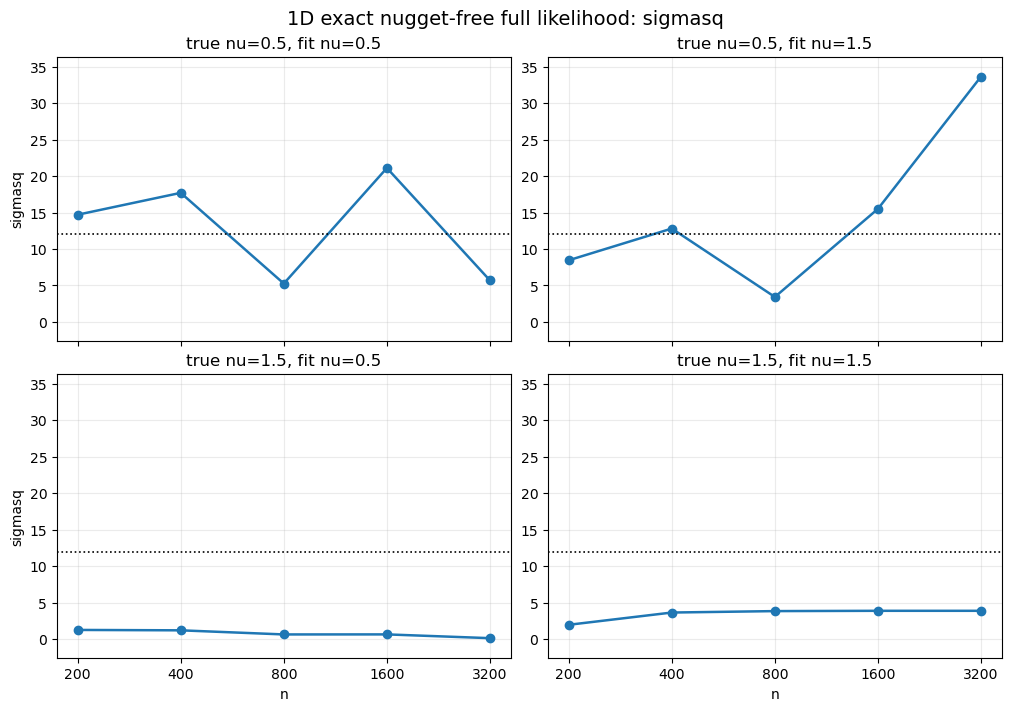

Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_1d_exact_nscale_nugget0_s05_s15_050826_range_nscale_grid.png


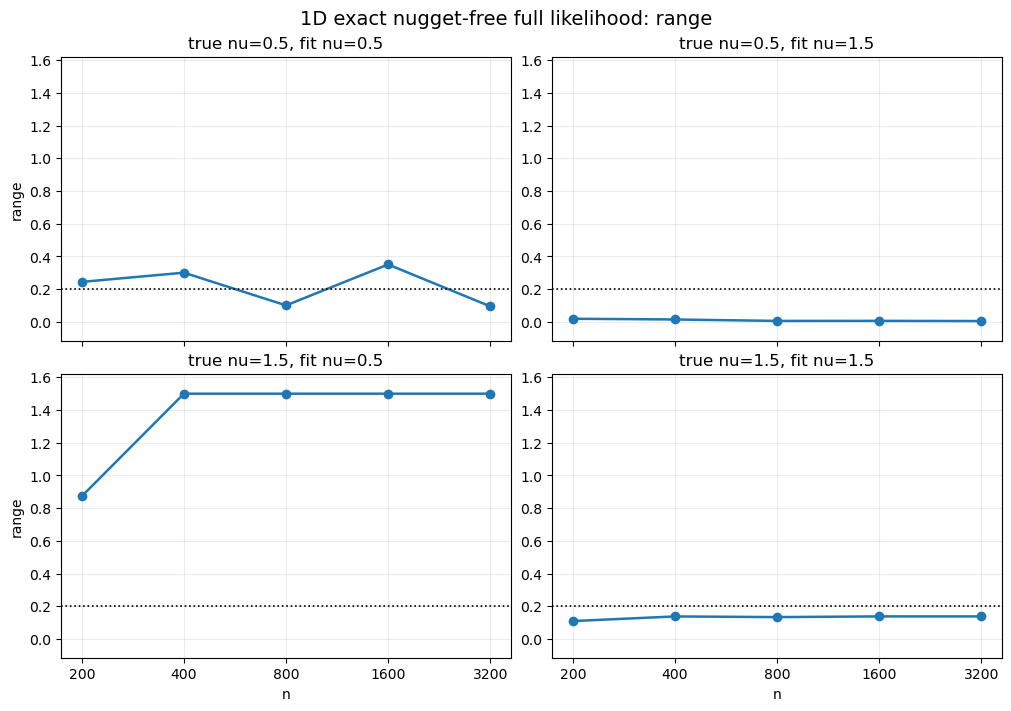

Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_1d_exact_nscale_nugget0_s05_s15_050826_microergodic_nscale_grid.png


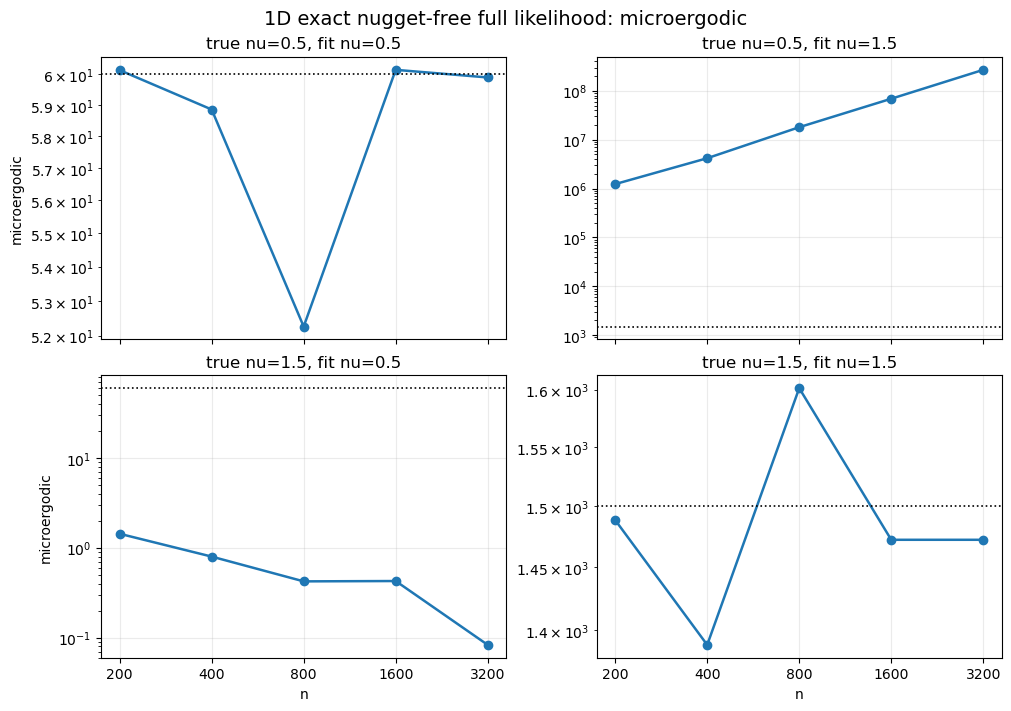

In [15]:
def plot_param(param):
    y_col = {'sigmasq': 'est_sigmasq', 'range': 'est_range', 'microergodic': 'est_microergodic_fitnu'}[param]
    truth = {'sigmasq': TRUE_PARAMS['sigmasq'], 'range': TRUE_PARAMS['range']} .get(param, None)
    fig, axes = plt.subplots(len(TRUE_SMOOTHS), len(FIT_SMOOTHS), figsize=(10, 7), constrained_layout=True, sharex=True)
    vals = pd.to_numeric(fit_df[y_col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    y_lim = None
    if not vals.empty and param != 'microergodic':
        lo, hi = float(vals.min()), float(vals.max())
        pad = 0.08 * (hi - lo) if hi > lo else 0.1 * max(abs(hi), 1.0)
        y_lim = (lo - pad, hi + pad)
    for i, true_smooth in enumerate(TRUE_SMOOTHS):
        for j, fit_smooth in enumerate(FIT_SMOOTHS):
            ax = axes[i, j]
            sub = fit_df[(fit_df['true_smooth'] == true_smooth) & (fit_df['fit_smooth'] == fit_smooth)].sort_values('n')
            ax.plot(sub['n'], sub[y_col], marker='o', linewidth=1.8)
            if truth is not None:
                ax.axhline(truth, color='black', linestyle=':', linewidth=1.2)
            if param == 'microergodic':
                ax.axhline(float(sub['true_microergodic_fitnu'].iloc[0]), color='black', linestyle=':', linewidth=1.2, label='truth under fit nu')
                ax.set_yscale('log')
            if y_lim is not None:
                ax.set_ylim(*y_lim)
            ax.set_xscale('log', base=2)
            ax.set_xticks(N_LIST, [str(n) for n in N_LIST])
            ax.set_title(f'true nu={true_smooth}, fit nu={fit_smooth}')
            ax.grid(True, alpha=0.25)
            if j == 0:
                ax.set_ylabel(param)
            if i == len(TRUE_SMOOTHS) - 1:
                ax.set_xlabel('n')
    fig.suptitle(f'1D exact nugget-free full likelihood: {param}', fontsize=14)
    out = OUT_DIR / f'{OUT_PREFIX}_{param}_nscale_grid.png'
    fig.savefig(out, dpi=180, bbox_inches='tight')
    print('Saved:', out)
    plt.show()


for param in ['sigmasq', 'range', 'microergodic']:
    plot_param(param)


Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/sim_1d_exact_nscale_nugget0_s05_s15_050826_loss_nscale.png


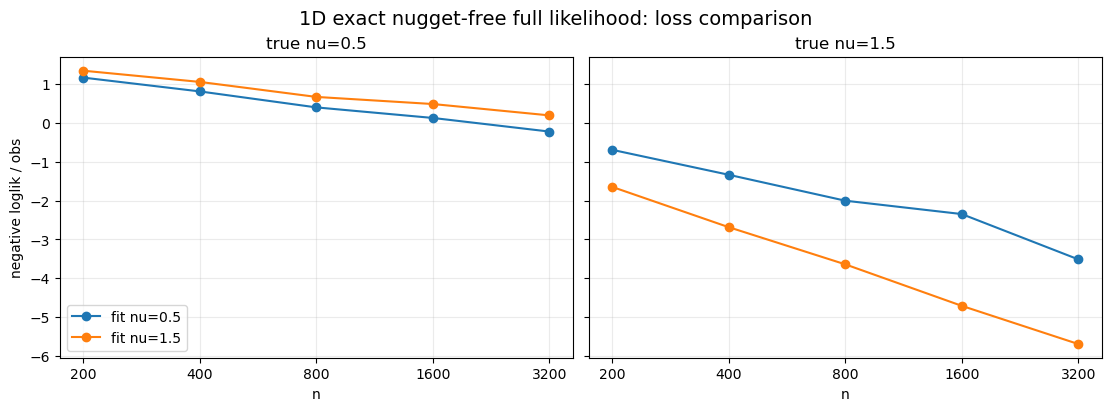

In [16]:
# Loss comparison.
fig, axes = plt.subplots(1, len(TRUE_SMOOTHS), figsize=(11, 4), constrained_layout=True, sharey=True)
for ax, true_smooth in zip(axes, TRUE_SMOOTHS):
    for fit_smooth in FIT_SMOOTHS:
        sub = fit_df[(fit_df['true_smooth'] == true_smooth) & (fit_df['fit_smooth'] == fit_smooth)].sort_values('n')
        ax.plot(sub['n'], sub['loss_per_obs'], marker='o', label=f'fit nu={fit_smooth}')
    ax.set_xscale('log', base=2)
    ax.set_xticks(N_LIST, [str(n) for n in N_LIST])
    ax.set_title(f'true nu={true_smooth}')
    ax.set_xlabel('n')
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel('negative loglik / obs')
axes[0].legend()
fig.suptitle('1D exact nugget-free full likelihood: loss comparison', fontsize=14)
out = OUT_DIR / f'{OUT_PREFIX}_loss_nscale.png'
fig.savefig(out, dpi=180, bbox_inches='tight')
print('Saved:', out)
plt.show()
